Задача: С помощью алгоритм Герцеля декодировать сигнал и восстановить исходную последовательность.
Алгоритм Гёрцеля позволяет эффективно вычислить отдельные бины ДПФ, соответствующие нужным частотам (697, 770, 852, 941, 1209, 1336, 1477, 1633 Гц), без расчета всего спектра

Алгоритм Гёрцеля — это, по сути, узкополосный КИХ-фильтр, настроенный на конкретную частоту f.

Цель: Вычислить X[k] (значение ДПФ для бина k) для сигнала x[n] длины N (количество отсчетов за 200 мс, у нас N = 44100 * 200  = 8820 отсчетов).

k — это порядковый номер частоты f в частотной сетке ДПФ. ДПФ раскладывает сигнал на N частот, и k указывает, какая именно из этих частот нас интересует.

α= 2πk / N - это скорость изменения фазы для бина k (это нужно, чтобы когда входной сигнал имеет частоту, точно соответствующую нашему α, комплексные векторы складывались синфазно). Без точного знания α мы не смогли бы отличить нужную нам частоту от всех остальных.

Например, за время 200.0 мс сигнал частотой 697 Гц совершит 139.4 полных колебаний. Это и есть значение k = 139.40.
За время 200.0 мс сигнал частотой 770 Гц совершит 154.0 полных колебаний.

cos(alpha) для целевой частоты, возвращает мощность сигнала на целевой частоте.

In [12]:
import numpy as np
import wave
import struct

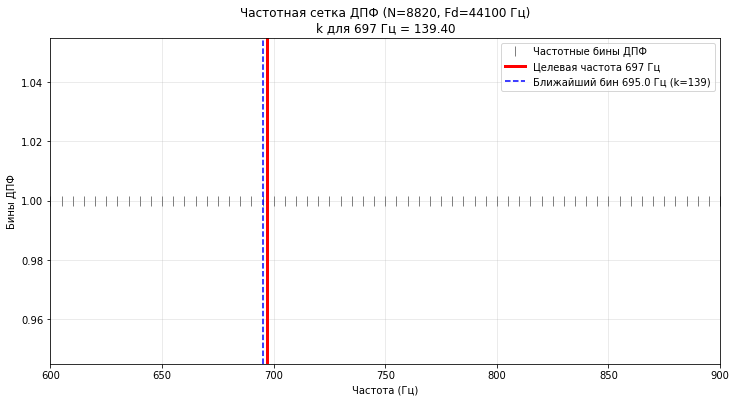

In [31]:
# Визуализируем частотную сетку ДПФ для 697 Гц
import matplotlib.pyplot as plt

def visualize_frequency_grid(f_target, N, F_d):
    # Создаем частотную сетку ДПФ
    frequencies = np.fft.fftfreq(N, 1/F_d)
    # Берем только положительные частоты (первую половину)
    positive_freq = frequencies[:N//2]
    
    # Вычисляем k для целевой частоты
    k_target = (f_target * N) / F_d
    # Ближайший целый бин
    k_nearest = round(k_target)
    freq_nearest = k_nearest * F_d / N
    
    plt.figure(figsize=(12, 6))
    
    # Рисуем частотную сетку
    plt.plot(positive_freq, np.ones_like(positive_freq), '|', color='gray', 
             markersize=10, label='Частотные бины ДПФ')
    
    # Отмечаем целевую частоту
    plt.axvline(f_target, color='red', linewidth=3, 
                label=f'Целевая частота {f_target} Гц')
    
    # Ближайший бин
    plt.axvline(freq_nearest, color='blue', linestyle='--', 
                label=f'Ближайший бин {freq_nearest:.1f} Гц (k={k_nearest})')
    
    plt.title(f'Частотная сетка ДПФ (N={N}, Fd={F_d} Гц)\n'
              f'k для {f_target} Гц = {k_target:.2f}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Бины ДПФ')
    plt.xlim(600, 900)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return k_target

k_697_viz = visualize_frequency_grid(697, N, F_d)

In [32]:
# Демонстрация почему k дробное
print("Если k ДРОБНОЕ?")
print("=" * 50)

frequencies_to_test = [697, 700, 770, 852]
for f in frequencies_to_test:
    k = detailed_calculate_k(f, N, F_d, verbose=False)
    k_int = round(k)
    freq_actual = k_int * F_d / N
    error = abs(freq_actual - f)
    
    print(f"f = {f:3} Гц → k = {k:6.2f} → ближайший бин {k_int:3} "
          f"→ частота {freq_actual:6.1f} Гц → ошибка {error:4.1f} Гц")

Если k ДРОБНОЕ?
f = 697 Гц → k = 139.40 → ближайший бин 139 → частота  695.0 Гц → ошибка  2.0 Гц
f = 700 Гц → k = 140.00 → ближайший бин 140 → частота  700.0 Гц → ошибка  0.0 Гц
f = 770 Гц → k = 154.00 → ближайший бин 154 → частота  770.0 Гц → ошибка  0.0 Гц
f = 852 Гц → k = 170.40 → ближайший бин 170 → частота  850.0 Гц → ошибка  2.0 Гц


Формулы для вычислений переменных в алгоритме Гёрцеля

In [13]:
# константы из условия
F_d = 44100  # Частота дискретизации
SYMBOL_DURATION = 0.2  # Длительность символа в секундах
PAUSE_DURATION = 0.1   # Длительность паузы в секундах

In [14]:
# Вычисляем k
k = (f_target * N) / F_d
print(f"k = ({f_target} * {N}) / {F_d} = {k}")

# Вычисляем α
alpha = 2 * np.pi * k / N
print(f"α = 2π × {k} / {N} = {alpha} радиан")

# Также в градусах 
alpha_deg = alpha * 180 / np.pi
print(f"α = {alpha_deg} градусов")

k = (697 * 8820) / 44100 = 139.4
α = 2π × 139.4 / 8820 = 0.09930567254204471 радиан
α = 5.689795918367348 градусов


In [15]:
# количество отсчетов для символа и паузы
N = int(F_d * SYMBOL_DURATION)  # Длина ДПФ (окна анализа)
samples_pause = int(F_d * PAUSE_DURATION)


In [16]:
# Определяем все частоты DTMF
dtmf_freqs = {
    '1': (697, 1209), '2': (697, 1336), '3': (697, 1477), 'A': (697, 1633),
    '4': (770, 1209), '5': (770, 1336), '6': (770, 1477), 'B': (770, 1633),
    '7': (852, 1209), '8': (852, 1336), '9': (852, 1477), 'C': (852, 1633),
    '*': (941, 1209), '0': (941, 1336), '#': (941, 1477), 'D': (941, 1633)
}

low_freqs = [697, 770, 852, 941]   # Низкочастотная группа
high_freqs = [1209, 1336, 1477, 1633] # Высокочастотная группа
target_freqs = low_freqs + high_freqs # Все целевые частоты

In [17]:
# Вычисление k-го бина ДПФ для заданной частоты f
def calculate_k(f, N, F_d):
    return (f * N) / F_d

In [18]:
# k и alpha для всех целевых частот

k_values = {}
alpha_values = {}
cos_alpha = {}

for f in target_freqs:
    k = calculate_k(f, N, F_d)
    alpha = (2 * np.pi * k) / N
    
    k_values[f] = k
    alpha_values[f] = alpha
    cos_alpha[f] = np.cos(alpha)

In [24]:
# Функция алгоритма Гёрцеля для вычисления мощности на заданной частоте. 
# Она проходит по всем отсчетам фрагмента сигнала, обновляя состояния фильтра, и в конце вычисляет мощность.

def goertzel(x, N, cos_alpha_val):
    """
    x: массив отсчетов сигнала (длиной N)
    N: количество отсчетов
    cos_alpha_val: предвычисленное значение 
    """
    # Инициализация состояний фильтра (s_{n-1} и s_{n-2})
    s_prev = 0.0
    s_prev2 = 0.0
    
    # Рекуррентная часть: проход по всем отсчетам
    for n in range(N):
        s_current = x[n] + 2 * cos_alpha_val * s_prev - s_prev2
        # Обновляем состояния для следующей итерации
        s_prev2 = s_prev
        s_prev = s_current
    
    # Вычисление мощности по финальным состояниям
    power = s_prev**2 + s_prev2**2 - 2 * cos_alpha_val * s_prev * s_prev2
    return power

In [28]:
def read_wav_file(filename):
    with wave.open(filename, 'rb') as wav_file:
        n_channels = wav_file.getnchannels()
        sampwidth = wav_file.getsampwidth()
        framerate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        
        frames = wav_file.readframes(n_frames)
        
        if sampwidth == 2:
            data = struct.unpack('<' + 'h' * n_frames * n_channels, frames)

        
        if n_channels == 2:
            data = np.array(data).reshape(-1, 2).mean(axis=1)
        else:
            data = np.array(data)
            
        return data, framerate

audio_signal, file_fs = read_wav_file('DTMF_Lab14.wav')



In [30]:
block_duration = SYMBOL_DURATION + PAUSE_DURATION
samples_per_block = int(F_d * block_duration)
total_blocks = len(audio_signal) // samples_per_block

decoded_sequence = []

for block_index in range(total_blocks): #символ + пауза
    start_sample = block_index * samples_per_block
    end_sample = start_sample + N
    segment = audio_signal[start_sample:end_sample]
    
    if len(segment) < N:
        continue
    
    power_results = {}
    for freq in target_freqs:
        power = goertzel(segment, N, cos_alpha[freq])
        power_results[freq] = power
    
    low_powers = {f: power_results[f] for f in low_freqs}
    high_powers = {f: power_results[f] for f in high_freqs}
    
    detected_low_freq = max(low_powers, key=low_powers.get)
    detected_high_freq = max(high_powers, key=high_powers.get)
    
    for symbol, (low, high) in dtmf_freqs.items():
        if low == detected_low_freq and high == detected_high_freq:
            decoded_sequence.append(symbol)
            break

print("Ответ для сигнала 14:", ''.join(decoded_sequence))

Ответ для сигнала 14: D4*5A6#7C8#9B0*A
